In [1]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
!cp "/content/drive/MyDrive/criteo-uplift-project/data/criteo-uplift-v2.1.csv" /content/

In [3]:
import pandas as pd

csv_path = "/content/criteo-uplift-v2.1.csv"

df = pd.read_csv(
    csv_path,
    low_memory=False
)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/criteo-uplift-v2.1.csv'

## 1. Dataset Overview

The dataset contains ~14 million observations from a randomized online advertising experiment.

Key variables:
- `treatment`: Whether user was shown an ad (1 = treated, 0 = control)
- `conversion`: Whether user purchased
- `visit`: Whether user visited site
- Remaining columns: anonymized user features

This dataset allows us to estimate heterogeneous treatment effects rather than only average effects.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979592 entries, 0 to 13979591
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   f0          float64
 1   f1          float64
 2   f2          float64
 3   f3          float64
 4   f4          float64
 5   f5          float64
 6   f6          float64
 7   f7          float64
 8   f8          float64
 9   f9          float64
 10  f10         float64
 11  f11         float64
 12  treatment   int64  
 13  conversion  int64  
 14  visit       int64  
 15  exposure    int64  
dtypes: float64(12), int64(4)
memory usage: 1.7 GB


From `df.describe()`, the mean of:
- `conversion` ≈ 2.92e-03 → 0.29%
- `visit` ≈ 4.70e-02 → 4.7%

Since these variables are binary (0/1), the mean represents the proportion of positive outcomes.  
Conversion rate is very low (0.29%), while visit rate is higher (4.7%),
suggesting a funnel structure (visit → conversion).


In [ ]:
df[df.duplicated()].head()
df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
count,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07,1.397959e+07
mean,1.962030e+01,1.006998e+01,8.446582e+00,4.178923e+00,1.033884e+01,4.028513e+00,-4.155356e+00,5.101765e+00,3.933581e+00,1.602764e+01,5.333396e+00,-1.709672e-01,8.500001e-01,2.916680e-03,4.699200e-02,3.063122e-02
std,5.377464e+00,1.047557e-01,2.993161e-01,1.336645e+00,3.433081e-01,4.310974e-01,4.577914e+00,1.205248e+00,5.665958e-02,7.018975e+00,1.682288e-01,2.283277e-02,3.570713e-01,5.392748e-02,2.116217e-01,1.723164e-01
min,1.261636e+01,1.005965e+01,8.214383e+00,-8.398387e+00,1.028053e+01,-9.011892e+00,-3.142978e+01,4.833815e+00,3.635107e+00,1.319006e+01,5.300375e+00,-1.383941e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.261636e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-6.699321e+00,4.833815e+00,3.910792e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.192341e+01,1.005965e+01,8.214383e+00,4.679882e+00,1.028053e+01,4.115453e+00,-2.411115e+00,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.443646e+01,1.005965e+01,8.723335e+00,4.679882e+00,1.028053e+01,4.115453e+00,2.944427e-01,4.833815e+00,3.971858e+00,1.319006e+01,5.300375e+00,-1.686792e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.674526e+01,1.634419e+01,9.051962e+00,4.679882e+00,2.112351e+01,4.115453e+00,2.944427e-01,1.199840e+01,3.971858e+00,7.529502e+01,6.473917e+00,-1.686792e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## Data Quality Checks: Missing, Duplicate, and Inconsistent Data
No missing values were detected.

Approximately 1.63 million rows share identical feature values. Of these,
1.26 million are exact duplicates across all columns, while the remaining
0.37 million share the same features but differ in treatment or outcomes.

This confirms that repeated feature combinations represent different users
or impressions rather than data errors. All observations were retained to
preserve the experimental structure.

Binary variables (treatment, conversion, visit, exposure) are properly encoded as 0/1.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(1259545)

In [ ]:
df[['treatment','conversion','visit','exposure']].nunique()

,0
treatment,2
conversion,2
visit,2
exposure,2


In [ ]:
df[df.duplicated()].head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
118,12.616365,10.059654,9.037786,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
201,12.616365,10.059654,8.867568,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
289,12.616365,10.059654,9.048241,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
398,12.616365,10.059654,8.887297,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4928,21.969037,10.059654,8.214383,4.679882,10.280525,4.115453,-4.595460,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


In [ ]:
# Check if duplicates are identical across ALL columns
df[df.duplicated(keep=False)].head(10)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
5,12.616365,10.059654,8.904507,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
10,12.616365,10.059654,8.807791,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
11,12.616365,10.059654,8.808535,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
14,12.616365,10.059654,9.002699,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
16,12.616365,10.059654,8.964672,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
17,12.616365,10.059654,8.784378,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
18,12.616365,10.059654,9.048241,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
20,12.616365,10.059654,9.027074,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [ ]:
# Feature-only duplicates
feature_cols = [c for c in df.columns if c.startswith('f')]

df.duplicated(subset=feature_cols).sum()

np.int64(1626259)

### Summary Statistics

The conversion rate is approximately 0.29%, while the visit rate is about 4.7%,
indicating strong class imbalance.

Approximately 85% of users received treatment, meaning the dataset is not
balanced between treated and control groups.

The median for both conversion and visit is 0, reflecting that most users
do not convert or visit.

Overall, positive outcomes are rare, reinforcing the need for uplift modeling
rather than standard classification.

In [ ]:
# Mean
means = df.mean()

# Median
medians = df.median()

# Standard deviation
stds = df.std()

means[['conversion','visit','treatment']], medians[['conversion','visit']], stds[['conversion','visit']]

(conversion    0.002917
 visit         0.046992
 treatment     0.850000
 dtype: float64,
 conversion    0.0
 visit         0.0
 dtype: float64,
 conversion    0.053927
 visit         0.211622
 dtype: float64)

### Advertising Impact Across Funnel Stages

Advertising increases visit rates from 3.82% (control) to 4.85% (treated),
indicating a clear positive effect on user engagement.

Conversion rates also increase from 0.19% to 0.31%, suggesting a positive
average treatment effect on purchases, although the absolute difference is small.

Among users who visited the site, the treated group shows a higher
conversion probability (6.36% vs 5.07%), implying that advertising not only
drives traffic but may also slightly influence purchasing behavior once users are engaged.

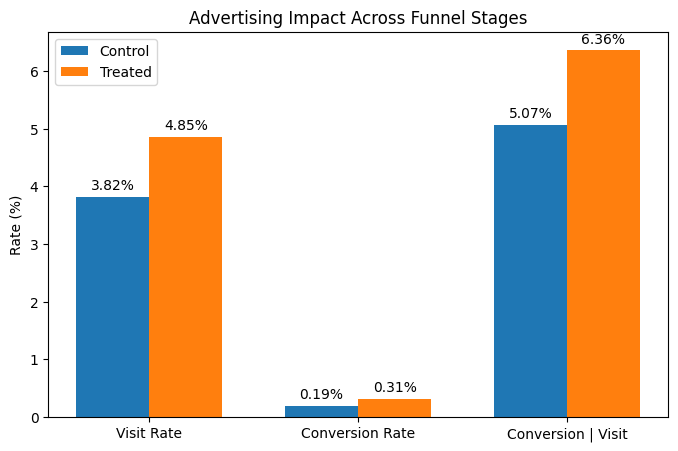

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute metrics
visit_rate = df.groupby('treatment')['visit'].mean() * 100
conversion_rate = df.groupby('treatment')['conversion'].mean() * 100
conv_given_visit = (
    df[df['visit'] == 1]
    .groupby('treatment')['conversion']
    .mean() * 100
)

labels = ['Visit Rate', 'Conversion Rate', 'Conversion | Visit']
control_values = [visit_rate[0], conversion_rate[0], conv_given_visit[0]]
treated_values = [visit_rate[1], conversion_rate[1], conv_given_visit[1]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, control_values, width, label='Control')
bars2 = ax.bar(x + width/2, treated_values, width, label='Treated')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Rate (%)")
ax.set_title("Advertising Impact Across Funnel Stages")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()

### Relative Lift from Advertising

Advertising has a noticeable proportional impact, especially on conversions.
While the absolute increase in conversion rate is small, the relative lift (~59%)
shows that advertising meaningfully improves outcomes compared to doing nothing.

The effect on visits (~27% lift) is smaller but still substantial, suggesting
that ads both drive traffic and improve the likelihood of purchase.

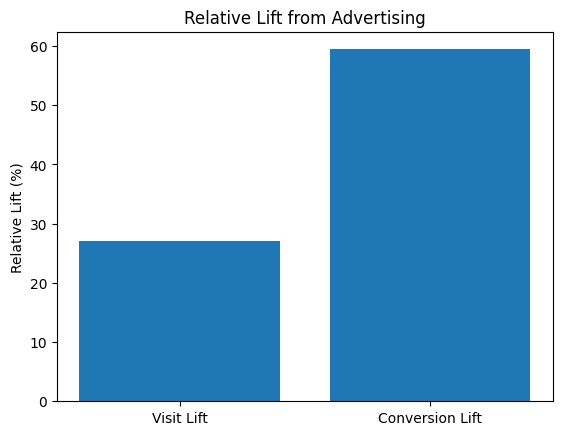

Visit Lift: 27.07%
Conversion Lift: 59.45%


In [ ]:
visit_control = visit_rate[0]
visit_treated = visit_rate[1]

conv_control = conversion_rate[0]
conv_treated = conversion_rate[1]

visit_lift = (visit_treated - visit_control) / visit_control * 100
conv_lift = (conv_treated - conv_control) / conv_control * 100

plt.bar(['Visit Lift','Conversion Lift'], [visit_lift, conv_lift])
plt.ylabel("Relative Lift (%)")
plt.title("Relative Lift from Advertising")
plt.show()

print(f"Visit Lift: {visit_lift:.2f}%")
print(f"Conversion Lift: {conv_lift:.2f}%")

### Correlation Between Treatment and Outcomes

The correlation between treatment and both visit (0.017) and conversion (0.008) is positive but very small, which is expected in a randomized experiment where the average treatment effect is modest.

Visit and conversion show a stronger positive correlation (0.24), indicating that users who visit the site are more likely to convert, consistent with a funnel structure.

Exposure is moderately correlated with visit (0.31), suggesting that increased ad exposure is associated with higher engagement.

Overall, the weak correlations between treatment and outcomes reinforce that the advertising effect exists but is relatively small in magnitude.

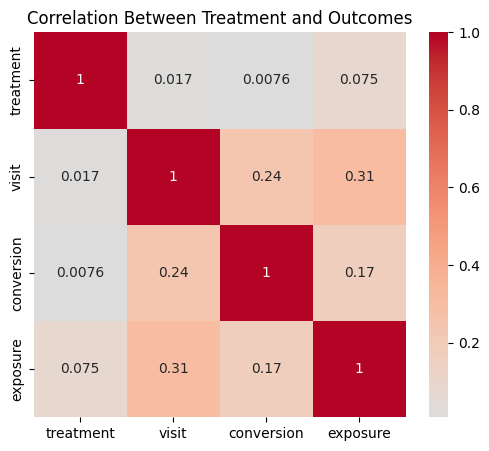

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['treatment', 'visit', 'conversion', 'exposure']

corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Between Treatment and Outcomes")
plt.show()

### PCA View of Conversion

In this plot, each point represents a user, and the red points are users who converted.

We do not see a clear cluster of red points separated from the blue ones.
Converters are spread throughout the feature space.

This means there is no obvious simple pattern that clearly separates converters
from non-converters. Conversion likely depends on more complex combinations
of features rather than one clear linear structure.

Conversion is rare and not trivially separable in low-dimensional space — which supports why uplift modeling (with nonlinear models) is appropriate.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import numpy as np
import matplotlib.pyplot as plt

feature_cols = [c for c in df.columns if c.startswith('f')]

# Sample for visualization (14M is too large to plot)
sample_df = df.sample(30000, random_state=42)

X = sample_df[feature_cols]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sample_df['PC1'] = X_pca[:, 0]
sample_df['PC2'] = X_pca[:, 1]

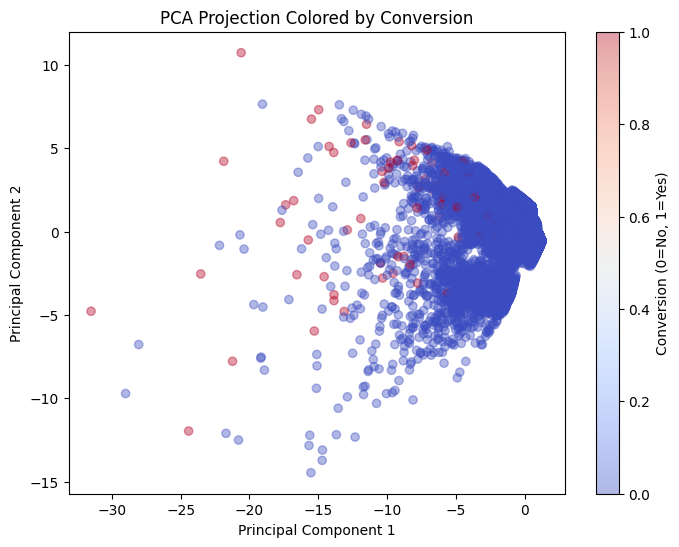

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    sample_df['PC1'],
    sample_df['PC2'],
    c=sample_df['conversion'],
    cmap='coolwarm',
    alpha=0.4
)

plt.colorbar(label="Conversion (0=No, 1=Yes)")
plt.title("PCA Projection Colored by Conversion")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
import os
os.makedirs("../precomputed", exist_ok=True)

# Computed rates
visit_rate.to_csv("precomputed/visit_rate.csv")
conversion_rate.to_csv("precomputed/conversion_rate.csv")
conv_given_visit.to_csv("precomputed/conv_given_visit.csv")

# Correlation matrix
df[['treatment', 'visit', 'conversion', 'exposure']].corr().round(2).to_csv("precomputed/corr.csv")

# PCA sample (5000 rows is enough for the scatter plot)
feature_cols = [c for c in df.columns if c.startswith('f')]
pca_sample = df[feature_cols + ['conversion']].sample(5000, random_state=42)
pca_sample.to_csv("precomputed/pca_sample.csv", index=False)

print("Done! Files saved:")
for f in os.listdir("../precomputed"):
    print(f" - precomputed/{f}")